In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

In [2]:

print(os.listdir('data/dataset'))

['.ipynb_checkpoints', 'city_attributes.csv', 'humidity.csv', 'pressure.csv', 'temperature.csv', 'weather_description.csv', 'wind_direction.csv', 'wind_speed.csv']


In [3]:


# File paths
base_path = "data/dataset/"
files = {
    "humidity": "humidity.csv",
    "pressure": "pressure.csv",
    "temperature": "temperature.csv",
    "weather": "weather_description.csv",  # Categorical
    "wind_dir": "wind_direction.csv",
    "wind_speed": "wind_speed.csv",         # Target
    "city_attr": "city_attributes.csv"
}

# Load all datasets into a dictionary
# Load all datasets except city_attributes
dfs = {}
for name, file in files.items():
    if name != "city_attr":  # Skip city_attributes for now
        df = pd.read_csv(base_path + file)
        df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])  # Parse datetime
        dfs[name] = df

# Load city_attributes separately (no datetime parsing)
city_attr = pd.read_csv(base_path + files["city_attr"])



# Merge all datasets for San Francisco
df = dfs["humidity"][["datetime", "San Francisco"]].rename(columns={"San Francisco": "humidity"})
df = df.merge(dfs["pressure"][["datetime", "San Francisco"]].rename(columns={"San Francisco": "pressure"}), on="datetime")
df = df.merge(dfs["temperature"][["datetime", "San Francisco"]].rename(columns={"San Francisco": "temperature"}), on="datetime")
df = df.merge(dfs["wind_dir"][["datetime", "San Francisco"]].rename(columns={"San Francisco": "wind_dir"}), on="datetime")
df = df.merge(dfs["weather"][["datetime", "San Francisco"]].rename(columns={"San Francisco": "weather_des"}), on="datetime")
df = df.merge(dfs["wind_speed"][["datetime", "San Francisco"]].rename(columns={"San Francisco": "wind_speed"}), on="datetime")


# Drop missing values
df.dropna(inplace=True)

# --- Unit conversions ---
df["temperature"] = df["temperature"] - 273.15        # Kelvin → Celsius
df["wind_speed"] = df["wind_speed"] * 3.6              # m/s → km/h

# --- Wind Direction Transformation (Circular Encoding) ---
df["wind_dir_sin"] = np.sin(np.deg2rad(df["wind_dir"]))
df["wind_dir_cos"] = np.cos(np.deg2rad(df["wind_dir"]))

# --- Encode weather description (categorical) ---
df['weather_des_encoded'], weather_labels = pd.factorize(df['weather_des'])
#print(weather_labels)

sf_info = city_attr[city_attr["City"] == "San Francisco"].iloc[0]
df["City"] = sf_info["City"]
df["Country"] = sf_info["Country"]
df["Latitude"] = sf_info["Latitude"]
df["Longitude"] = sf_info["Longitude"]

# Final cleaned dataframe
df_final = df[[
    "datetime", "humidity", "pressure", "temperature",
    "wind_dir_sin", "wind_dir_cos", "weather_des_encoded",
    "wind_speed", "City", "Country", "Latitude", "Longitude"
]]

# Optional: First 240 rows (~10 days if hourly)
sf_data = df_final.head(240)

# Preview
print(sf_data)


                datetime  humidity  pressure  temperature  wind_dir_sin  \
1    2012-10-01 13:00:00      88.0    1009.0    16.330000      0.500000   
2    2012-10-01 14:00:00      87.0    1009.0    16.324993      0.544639   
3    2012-10-01 15:00:00      86.0    1009.0    16.310618      0.629320   
4    2012-10-01 16:00:00      85.0    1009.0    16.296243      0.707107   
5    2012-10-01 17:00:00      84.0    1009.0    16.281869      0.777146   
..                   ...       ...       ...          ...           ...   
236  2012-10-11 08:00:00      82.0    1015.0    13.400000     -0.984808   
237  2012-10-11 09:00:00      82.0    1015.0    13.120000     -0.939693   
238  2012-10-11 10:00:00     100.0    1019.0    12.760000      0.000000   
239  2012-10-11 11:00:00      82.0    1014.0    12.560000     -1.000000   
240  2012-10-11 12:00:00      93.0    1014.0    12.450000      0.000000   

     wind_dir_cos  weather_des_encoded  wind_speed           City  \
1   -8.660254e-01             

In [4]:
# ----------- SCALE FEATURES -----------
# Copy original
df_scaled = df_final.copy()

# Pick numeric columns but exclude Latitude & Longitude
numeric_cols = df_scaled.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.drop(["Latitude", "Longitude"], errors="ignore")

# Scale only the selected numeric columns
scaler = MinMaxScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

# Keep datetime, Country, Latitude, Longitude unchanged
print(df_scaled.head(240))

# Save preprocessed data
df_scaled.to_csv("preprocessed_sf_weather.csv", index=False)


                datetime  humidity  pressure  temperature  wind_dir_sin  \
1    2012-10-01 13:00:00  0.872340  0.406780     0.415779      0.750000   
2    2012-10-01 14:00:00  0.861702  0.406780     0.415658      0.772320   
3    2012-10-01 15:00:00  0.851064  0.406780     0.415310      0.814660   
4    2012-10-01 16:00:00  0.840426  0.406780     0.414962      0.853553   
5    2012-10-01 17:00:00  0.829787  0.406780     0.414614      0.888573   
..                   ...       ...       ...          ...           ...   
236  2012-10-11 08:00:00  0.808511  0.508475     0.344869      0.007596   
237  2012-10-11 09:00:00  0.808511  0.508475     0.338093      0.030154   
238  2012-10-11 10:00:00  1.000000  0.576271     0.329380      0.500000   
239  2012-10-11 11:00:00  0.808511  0.491525     0.324540      0.000000   
240  2012-10-11 12:00:00  0.925532  0.491525     0.321878      0.500000   

     wind_dir_cos  weather_des_encoded  wind_speed           City  \
1        0.066987             

In [5]:
# ----- Height Adjustment Using Logarithmic Wind Profile -----

# Parameters
z_target = 80   # desired height in meters
z_ref = 10      # measurement height in meters
z0 = 0.03       # roughness length for open flat terrain

# Apply formula (assuming df_scaled has a "wind_speed" column at z_ref)
df_scaled["wind_speed_adj"] = df_scaled["wind_speed"] * (
    np.log(z_target / z0) / np.log(z_ref / z0)
)


In [6]:
print(df_scaled.head(240))

                datetime  humidity  pressure  temperature  wind_dir_sin  \
1    2012-10-01 13:00:00  0.872340  0.406780     0.415779      0.750000   
2    2012-10-01 14:00:00  0.861702  0.406780     0.415658      0.772320   
3    2012-10-01 15:00:00  0.851064  0.406780     0.415310      0.814660   
4    2012-10-01 16:00:00  0.840426  0.406780     0.414962      0.853553   
5    2012-10-01 17:00:00  0.829787  0.406780     0.414614      0.888573   
..                   ...       ...       ...          ...           ...   
236  2012-10-11 08:00:00  0.808511  0.508475     0.344869      0.007596   
237  2012-10-11 09:00:00  0.808511  0.508475     0.338093      0.030154   
238  2012-10-11 10:00:00  1.000000  0.576271     0.329380      0.500000   
239  2012-10-11 11:00:00  0.808511  0.491525     0.324540      0.000000   
240  2012-10-11 12:00:00  0.925532  0.491525     0.321878      0.500000   

     wind_dir_cos  weather_des_encoded  wind_speed           City  \
1        0.066987             

In [7]:

from sklearn.linear_model import LinearRegression
from sklearn.utils import resample

def swan_feature_selection(X, y, n_iterations=50, sample_frac=0.8, top_k=6):
    """
    Subsampling Winner Algorithm for feature ranking.
    - X: DataFrame of features
    - y: Series target
    Returns: list of top_k feature names
    """
    scores = pd.Series(0, index=X.columns, dtype=float)

    for _ in range(n_iterations):
        X_samp, y_samp = resample(X, y, n_samples=int(len(X) * sample_frac))
        model = LinearRegression().fit(X_samp, y_samp)
        coefs = pd.Series(np.abs(model.coef_), index=X.columns)
        ranks = coefs.rank(ascending=False)
        scores += (len(X.columns) + 1) - ranks

    averaged_scores = scores / n_iterations
    return averaged_scores.nlargest(top_k).index.tolist()

# Example usage:
features = df_final.drop(
    columns=["datetime", "wind_speed", "City", "Country"]
).select_dtypes(include=[np.number])

target = df_final["wind_speed"]

selected = swan_feature_selection(
    features, target,
    n_iterations=100, sample_frac=0.8, top_k=6
)
print("Selected features:", selected)


Selected features: ['wind_dir_sin', 'wind_dir_cos', 'weather_des_encoded', 'pressure', 'humidity', 'temperature']


In [8]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVR

def haok_feature_selection_fast(X, y, top_k=6, sample_size=500):
    if len(X) > sample_size:
        X = X.sample(n=sample_size, random_state=42)
        y = y.loc[X.index]

    model = SVR(kernel="linear")  # <-- linear so coef_ is available
    selector = RFE(model, n_features_to_select=top_k, step=1)
    selector = selector.fit(X, y)
    return X.columns[selector.support_].tolist()

haok_selected = haok_feature_selection_fast(features, target, top_k=6)
print("HAOK selected features:", haok_selected)


HAOK selected features: ['humidity', 'pressure', 'temperature', 'wind_dir_sin', 'wind_dir_cos', 'weather_des_encoded']


In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# ==== 1. Use only your selected features ====
#selected_features = ['humidity', 'pressure', 'temperature', 'wind_dir_sin', 'wind_dir_cos', 'weather_des_encoded']
X = df_final[haok_selected].values

# ==== 2. Normalize for better AE performance ====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==== 3. Autoencoder architecture ====
input_dim = X_scaled.shape[1]   # number of features
encoding_dim = 3                # compressed latent dimension (tune this)

# Input Layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(6, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(6, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Autoencoder Model
autoencoder = Model(inputs=input_layer, outputs=decoded)

# Encoder Model (for feature extraction)
encoder = Model(inputs=input_layer, outputs=encoded)

# Compile Autoencoder
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# ==== 4. Train Autoencoder ====
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=25,
    batch_size=16,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)

# ==== 5. Extract new features ====
X_encoded = encoder.predict(X_scaled)

# Convert to DataFrame
encoded_df = pd.DataFrame(X_encoded, columns=[f'AE_Feature_{i+1}' for i in range(encoding_dim)])

print(encoded_df.head())

# ==== 6. Merge back with target for forecasting ====
#df_with_ae = pd.concat([encoded_df, df_final[['datetime', 'wind_speed']]], axis=1)
df_with_ae = pd.concat(
    [pd.DataFrame(X_encoded, columns=[f'AE_Feature_{i+1}' for i in range(encoding_dim)]),
     df_final[['datetime', 'wind_speed']].reset_index(drop=True)],
    axis=1
)

Epoch 1/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.5455 - val_loss: 0.6069
Epoch 2/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3505 - val_loss: 0.5564
Epoch 3/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3279 - val_loss: 0.5558
Epoch 4/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3219 - val_loss: 0.5490
Epoch 5/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.3172 - val_loss: 0.5336
Epoch 6/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3140 - val_loss: 0.5328
Epoch 7/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3122 - val_loss: 0.5231
Epoch 8/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3110 - val_loss: 0.5136
Epoch 9/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.3099 - val_loss: 0.5133
Epoch 10/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.3086 - val_loss: 0.5137
Epoch 11/25
2216/2216 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.3069 - val_loss: 0.5211
Epoch 12/25
2216/2216 ━━━━━━━━

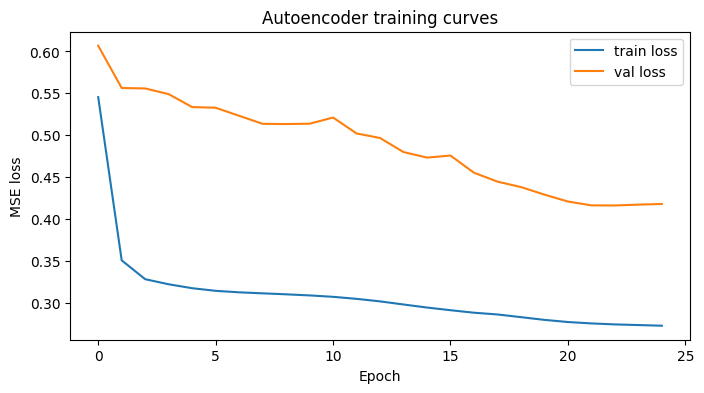

In [10]:
import matplotlib.pyplot as plt

hist = history.history  # Keras History object from autoencoder.fit(...)
plt.figure(figsize=(8,4))
plt.plot(hist['loss'], label='train loss')
plt.plot(hist['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.title('Autoencoder training curves')
plt.show()


In [11]:
# ==== After HAOK and Autoencoder step ====

# Ensure datetime sorted
df_with_ae = df_with_ae.sort_values("datetime").reset_index(drop=True)

# ==== Use AE Features instead of HAOK ====
X_data = df_with_ae[[f'AE_Feature_{i+1}' for i in range(encoding_dim)]].values
y_data = df_with_ae['wind_speed'].values

# ==== Sliding window function ====
def create_sliding_window(X, y, window_size=24, horizon=1):
    Xs, ys = [], []
    for i in range(len(X) - window_size - horizon + 1):
        # Take past window_size steps
        Xs.append(X[i:(i + window_size)])
        # Predict next horizon step
        ys.append(y[i + window_size + horizon - 1])
    return np.array(Xs), np.array(ys)

# ==== Apply Sliding Window ====
X_seq, y_seq = create_sliding_window(X_data, y_data, window_size=24, horizon=1)

print("Input shape:", X_seq.shape)   # (samples, 24, encoding_dim)
print("Output shape:", y_seq.shape)  # (samples,)


Input shape: (44280, 24, 3)
Output shape: (44280,)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.model_selection import train_test_split

# ----------------------------
# STEP 0: Example dataset prep
# ----------------------------
# Assume you already have your sliding-window dataset (X, y)
# For demo, let's make dummy data (replace with your real X, y)
# X shape -> (samples, timesteps, features)
# y shape -> (samples, 1)
samples, timesteps, features = 1000, 24, 6
X = np.random.rand(samples, timesteps, features)
y = np.random.rand(samples, 1)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)

# ----------------------------
# STEP 1: Taguchi L9 array
# ----------------------------
taguchi_array = [
    #(0.001, 128, 64),
    #(0.0005, 128, 64),
    #(0.0005, 128, 32),
    #(0.0005, 128, 128),
    #(0.001, 64, 32),
    #(0.001, 96, 64),
    #(0.001, 128, 128),
    #(0.0005, 64, 64),
    #(0.0005, 96, 128),
    #(0.0005, 128, 32),
    #(0.0001, 64, 128),
    #(0.0001, 96, 32),
    #(0.0001, 128, 64),
    (0.01,128,64)
    
    
]

# ----------------------------
# STEP 2: Evaluation function
# ----------------------------
def evaluate(params, X_train, y_train, X_val, y_val):
    lr, units, batch = params

    model = Sequential([
        GRU(units, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="mae")

    history = model.fit(
        X_train, y_train,
        epochs=20, # keep small for Taguchi search
        batch_size=batch,
        validation_data=(X_val, y_val),
        verbose=0
    )

    val_loss = min(history.history["val_loss"])  # best val_loss
    return val_loss

# ----------------------------
# STEP 3: Run Taguchi
# ----------------------------
results = []
for params in taguchi_array:
    score = evaluate(params, X_train, y_train, X_val, y_val)
    results.append((params, score))
    print(f"Params: {params} --> Validation Loss={score:.4f}")

# ----------------------------
# STEP 4: Best parameters
# ----------------------------
best_params, best_score = min(results, key=lambda x: x[1])
print("\nBest Hyperparameters (Taguchi Selection):")
print(f"Learning Rate: {best_params[0]}")
print(f"Units: {best_params[1]}")
print(f"Batch Size: {best_params[2]}")
print(f"Best Val Loss: {best_score:.4f}")


Train shape: (800, 24, 6) (800, 1)
Val shape: (200, 24, 6) (200, 1)


c:\Users\SILAMBARASAN R\Wind_speed_forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Params: (0.01, 128, 64) --> Validation Loss=0.2582

Best Hyperparameters (Taguchi Selection):
Learning Rate: 0.01
Units: 128
Batch Size: 64
Best Val Loss: 0.2582


In [13]:
best_params, best_score = min(results, key=lambda x: x[1])
best_lr, best_units, best_batch = best_params


In [ ]:
import os
import random

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# ----------------------------
# STEP 0: Reproducibility setup
# ----------------------------
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'   # enforce deterministic ops (if supported)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ----------------------------
# STEP 1: Sliding window function
# ----------------------------
def create_sliding_window(X, y, window_size=24, horizon=1):
    Xs, ys = [], []
    for i in range(len(X) - window_size - horizon + 1):
        Xs.append(X[i:(i + window_size)])
        ys.append(y[i + window_size + horizon - 1])
    return np.array(Xs), np.array(ys)

# ----------------------------
# STEP 2: Data preparation
# ----------------------------
target = "wind_speed"

# scale target only
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df[[target]].values)

# if you’re using AE features, replace with df_with_ae
X_data = df_with_ae[[f'AE_Feature_{i+1}' for i in range(encoding_dim)]].values
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)

# sliding window
X_seq, y_seq = create_sliding_window(X_scaled, y_scaled, window_size=24, horizon=1)

# reproducible train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=True, random_state=SEED
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# ----------------------------
# STEP 3: GRU Model (with Taguchi params)
# ----------------------------
best_lr, best_units, best_batch = best_params   # <- fetched from Taguchi

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(best_units, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1)  # output: next-hour wind speed
])

model.compile(optimizer=Adam(learning_rate=best_lr), loss="mse", metrics=["mae"])

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=best_batch,    # <- from Taguchi
    callbacks=[early_stop],
    verbose=1
)

# ----------------------------
# STEP 4: Predictions (inverse scaled)
# ----------------------------
y_pred_train = scaler_y.inverse_transform(model.predict(X_train))
y_pred_test = scaler_y.inverse_transform(model.predict(X_test))

y_train_inv = scaler_y.inverse_transform(y_train.reshape(-1,1))
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1))

# ----------------------------
# STEP 5: Show sample outputs
# ----------------------------
print("\n--- Training Samples ---")
for i in range(10):
    print(f"Sample {i+1}: Actual={y_train_inv[i][0]:.3f}, Predicted={y_pred_train[i][0]:.3f}")

print("\n--- Testing Samples ---")
for i in range(10):
    print(f"Sample {i+1}: Actual={y_test_inv[i][0]:.3f}, Predicted={y_pred_test[i][0]:.3f}")


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# Example training data (replace with your dataset)
X_train = np.random.rand(500, 10, 1)
y_train = np.random.rand(500, 1)
X_test = np.random.rand(100, 10, 1)
y_test = np.random.rand(100, 1)

# Baseline GRU model
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(10, 1)),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
history = gru_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Predictions
y_pred = gru_model.predict(X_test[:10])
for i in range(10):
    print(f"Sample {i+1}: Actual={y_test[i][0]:.3f}, Predicted={y_pred[i][0]:.3f}")

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Baseline GRU Loss")
plt.show()


In [23]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Quantum device (simulator with 2 qubits)
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

# Define a simple quantum circuit
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

# Convert circuit into a TorchLayer
weight_shapes = {"weights": (3, n_qubits)}  # 3 layers, 2 qubits
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# Hybrid GRU + Quantum model
class HybridModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(HybridModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, n_qubits)   # map GRU → qubit inputs
        self.q_layer = quantum_layer
        self.fc2 = nn.Linear(n_qubits, output_size)   # final regression output

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]        # last hidden state
        out = self.fc1(out)
        out = self.q_layer(out)
        out = self.fc2(out)
        return out


In [24]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


In [25]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Encode classical data into qubits
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    
    # Variational quantum circuit (trainable weights)
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    
    # Return expectation values
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


In [26]:
weight_shapes = {"weights": (3, n_qubits, 3)}  # 3 layers, 4 qubits, 3 params each


In [27]:
from pennylane.qnn import TorchLayer

quantum_layer = TorchLayer(quantum_circuit, weight_shapes)


In [28]:
class HybridGRUQNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(HybridGRUQNN, self).__init__()
        
        # GRU for sequence modeling
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layer to reduce GRU output to 4 (to match qubits)
        self.fc1 = nn.Linear(hidden_size, n_qubits)
        
        # Quantum layer
        self.q_layer = quantum_layer
        
        # Final output layer
        self.fc2 = nn.Linear(n_qubits, output_size)
    
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]            # take last time step
        out = self.fc1(out)            # reduce to qubits
        out = self.q_layer(out)        # quantum processing
        out = self.fc2(out)            # final prediction
        return out


In [29]:
input_size = 1       # wind speed input per timestep
hidden_size = 16
num_layers = 1
output_size = 1      # predict next wind speed

model = HybridGRUQNN(input_size, hidden_size, num_layers, output_size)
print(model)


HybridGRUQNN(
  (gru): GRU(1, 16, batch_first=True)
  (fc1): Linear(in_features=16, out_features=4, bias=True)
  (q_layer): <Quantum Torch Layer: func=quantum_circuit>
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)


In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Define GRU model
model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    GRU(32),
    Dense(1)  # Final prediction layer
])

model_gru.compile(optimizer='adam', loss='mse')

# Train GRU
history_gru = model_gru.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/20


c:\Users\SILAMBARASAN R\Wind_speed_forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.1378 - val_loss: 0.1117
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0958 - val_loss: 0.0945
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0879 - val_loss: 0.0905
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0876 - val_loss: 0.0885
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0864 - val_loss: 0.0881
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0861 - val_loss: 0.0875
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0858 - val_loss: 0.0872
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0856 - val_loss: 0.0869
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0854 - val_loss: 0.0866
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0853 - val_loss: 0.0864
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0851 - val_loss: 0.0862
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0850 - val_l

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Predictions from GRU model
y_pred_gru = model_gru.predict(X_test)

mse_gru = mean_squared_error(y_test, y_pred_gru)
mae_gru = mean_absolute_error(y_test, y_pred_gru)
rmse_gru = np.sqrt(mse_gru)

print("GRU Model Performance:")
print("MSE:", mse_gru)
print("RMSE:", rmse_gru)
print("MAE:", mae_gru)


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/stepWARNING:tensorflow:5 out of the last 1389 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000197D91FFBA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
GRU Model Performance:
MSE: 0.08099616022480678
RMSE: 0.2845982435378103
MAE: 0.24557463779069102


In [45]:
# Keep your original X_train, X_test safe
X_train_gru = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_gru  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))



print("X_train_gru shape:", X_train_gru.shape)
print("X_test_gru shape:", X_test_gru.shape)


X_train_gru shape: (500, 10, 1)
X_test_gru shape: (100, 10, 1)


In [43]:
print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)
print(X_train.shape, X_test.shape)


Original X_train shape: (500, 10, 1)
Original X_test shape: (100, 10, 1)
(500, 10, 1) (100, 10, 1)


In [40]:
y_train = y_train.reshape(-1, 1)   # (500, 1)
y_test = y_test.reshape(-1, 1)     # (100, 1)


In [46]:
import numpy as np
import pandas as pd

# ---------------------------
# STEP 1: Sliding Window Function
# ---------------------------
def create_sliding_window(X, y, window_size=24, horizon=1):
    Xs, ys = [], []
    for i in range(len(X) - window_size - horizon + 1):
        Xs.append(X[i:(i + window_size)])
        ys.append(y[i + window_size + horizon - 1])
    return np.array(Xs), np.array(ys)

# ---------------------------
# STEP 2: Example Dataset (replace with your wind speed data)
# ---------------------------
# Assume `data` is a pandas Series or numpy array of wind speeds
# Example dummy data for testing
data = np.sin(np.linspace(0, 50, 500))  # 500 time steps of fake wind data

# ---------------------------
# STEP 3: Create Sliding Windows
# ---------------------------
window_size = 24   # past 24 hours
horizon = 1        # predict next 1 hour

X, y = create_sliding_window(data, data, window_size, horizon)

print("Before reshape:")
print("X shape:", X.shape)  # (num_samples, 24)
print("y shape:", y.shape)  # (num_samples,)

# ---------------------------
# STEP 4: Reshape for GRU/QNN
# ---------------------------
X = X.reshape((X.shape[0], X.shape[1], 1))  # (samples, 24, 1)
y = y.reshape(-1, 1)                        # (samples, 1)

print("\nAfter reshape:")
print("X shape:", X.shape)  # (num_samples, 24, 1)
print("y shape:", y.shape)  # (num_samples, 1)

# ---------------------------
# STEP 5: Train-Test Split
# ---------------------------
split = int(0.8 * len(X))  # 80% train, 20% test

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("\nTrain-Test Split Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Before reshape:
X shape: (476, 24)
y shape: (476,)

After reshape:
X shape: (476, 24, 1)
y shape: (476, 1)

Train-Test Split Shapes:
X_train: (380, 24, 1)
X_test : (96, 24, 1)
y_train: (380, 1)
y_test : (96, 1)


In [49]:
# Step 1: Apply sliding window
window_size = 24   # for example
horizon = 1

X, y = create_sliding_window(scaled_data, scaled_data, window_size, horizon)

print("X shape:", X.shape)  # (samples, window_size, features)
print("y shape:", y.shape)  # (samples,)


NameError: name 'scaled_data' is not defined

In [48]:
# ✅ Train Hybrid GRU-QNN Model
history_hybrid = hybrid_model.fit(
    X_train_gru, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_gru, y_test),
    verbose=1
)

# ✅ Predictions (keep same shape as y_test)
y_pred_hybrid = hybrid_model.predict(X_test_gru)
y_pred_hybrid = y_pred_hybrid.reshape(-1)   # (N, ) for evaluation
y_test_flat  = y_test.reshape(-1)           # (N, )

# ✅ Evaluation
mse_hybrid = mean_squared_error(y_test_flat, y_pred_hybrid)
mae_hybrid = mean_absolute_error(y_test_flat, y_pred_hybrid)
rmse_hybrid = np.sqrt(mse_hybrid)

print("\nHybrid GRU-QNN Model Performance:")
print("MSE:", mse_hybrid)
print("RMSE:", rmse_hybrid)
print("MAE:", mae_hybrid)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 500
'y' sizes: 380
